In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

/tmp/ipykernel_1126739/315889740.py:22: RuntimeWarning: divide by zero encountered in divide
  return p / (1 - p)
/tmp/ipykernel_1126739/315889740.py:25: RuntimeWarning: divide by zero encountered in divide
  return np.log(L) / (n * alpha)


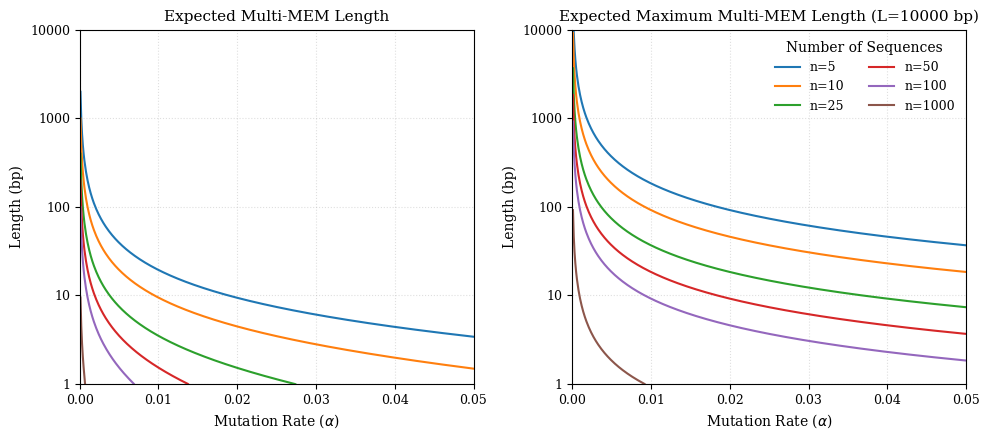

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif", "Times"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

alpha = np.linspace(0.000, 0.05, 500)
n_values = [5, 10, 25, 50, 100, 1000]
L_total = 10000 

def expected_length(alpha, n):
    p = (1 - alpha) ** n
    return p / (1 - p)

def expected_max_length(alpha, n, L):
    return np.log(L) / (n * alpha)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

for i, n in enumerate(n_values):
    E = expected_length(alpha, n)
    E_max = expected_max_length(alpha, n, L=L_total)
    
    # Subplot 1: Average Match Length
    ax1.plot(alpha, E, linestyle='-', linewidth=1.5, label=f"n={n}")
    
    # Subplot 2: Global Maximum Match Length
    ax2.plot(alpha, E_max, linestyle='-', linewidth=1.5, label=f"n={n}")

# Formatting Subplot 1: Local Average
ax1.set_title(r"Expected Multi-MEM Length")
ax1.set_xlabel(r"Mutation Rate ($\alpha$)")
ax1.set_ylabel(r"Length (bp)")

# Formatting Subplot 2: Global Maximum
ax2.set_title(r"Expected Maximum Multi-MEM Length (L=10000 bp)")
ax2.set_xlabel(r"Mutation Rate ($\alpha$)")
ax2.set_ylabel(r"Length (bp)")
ax2.legend(title="Number of Sequences", ncol=2, frameon=False)

for ax in [ax1, ax2]:
    ax.set_yscale("symlog", linthresh=1)
    ax.yaxis.set_major_formatter(ScalarFormatter())
    ax.set_xlabel(r"Mutation Rate ($\alpha$)")
    ax.set_xlim(0, 0.05)
    ax.set_ylim(1, 10000)
    ax.grid(True, which="both", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.savefig("theoretical_fig.png", dpi=300)
plt.savefig("theoretical_fig.pdf", dpi=300)

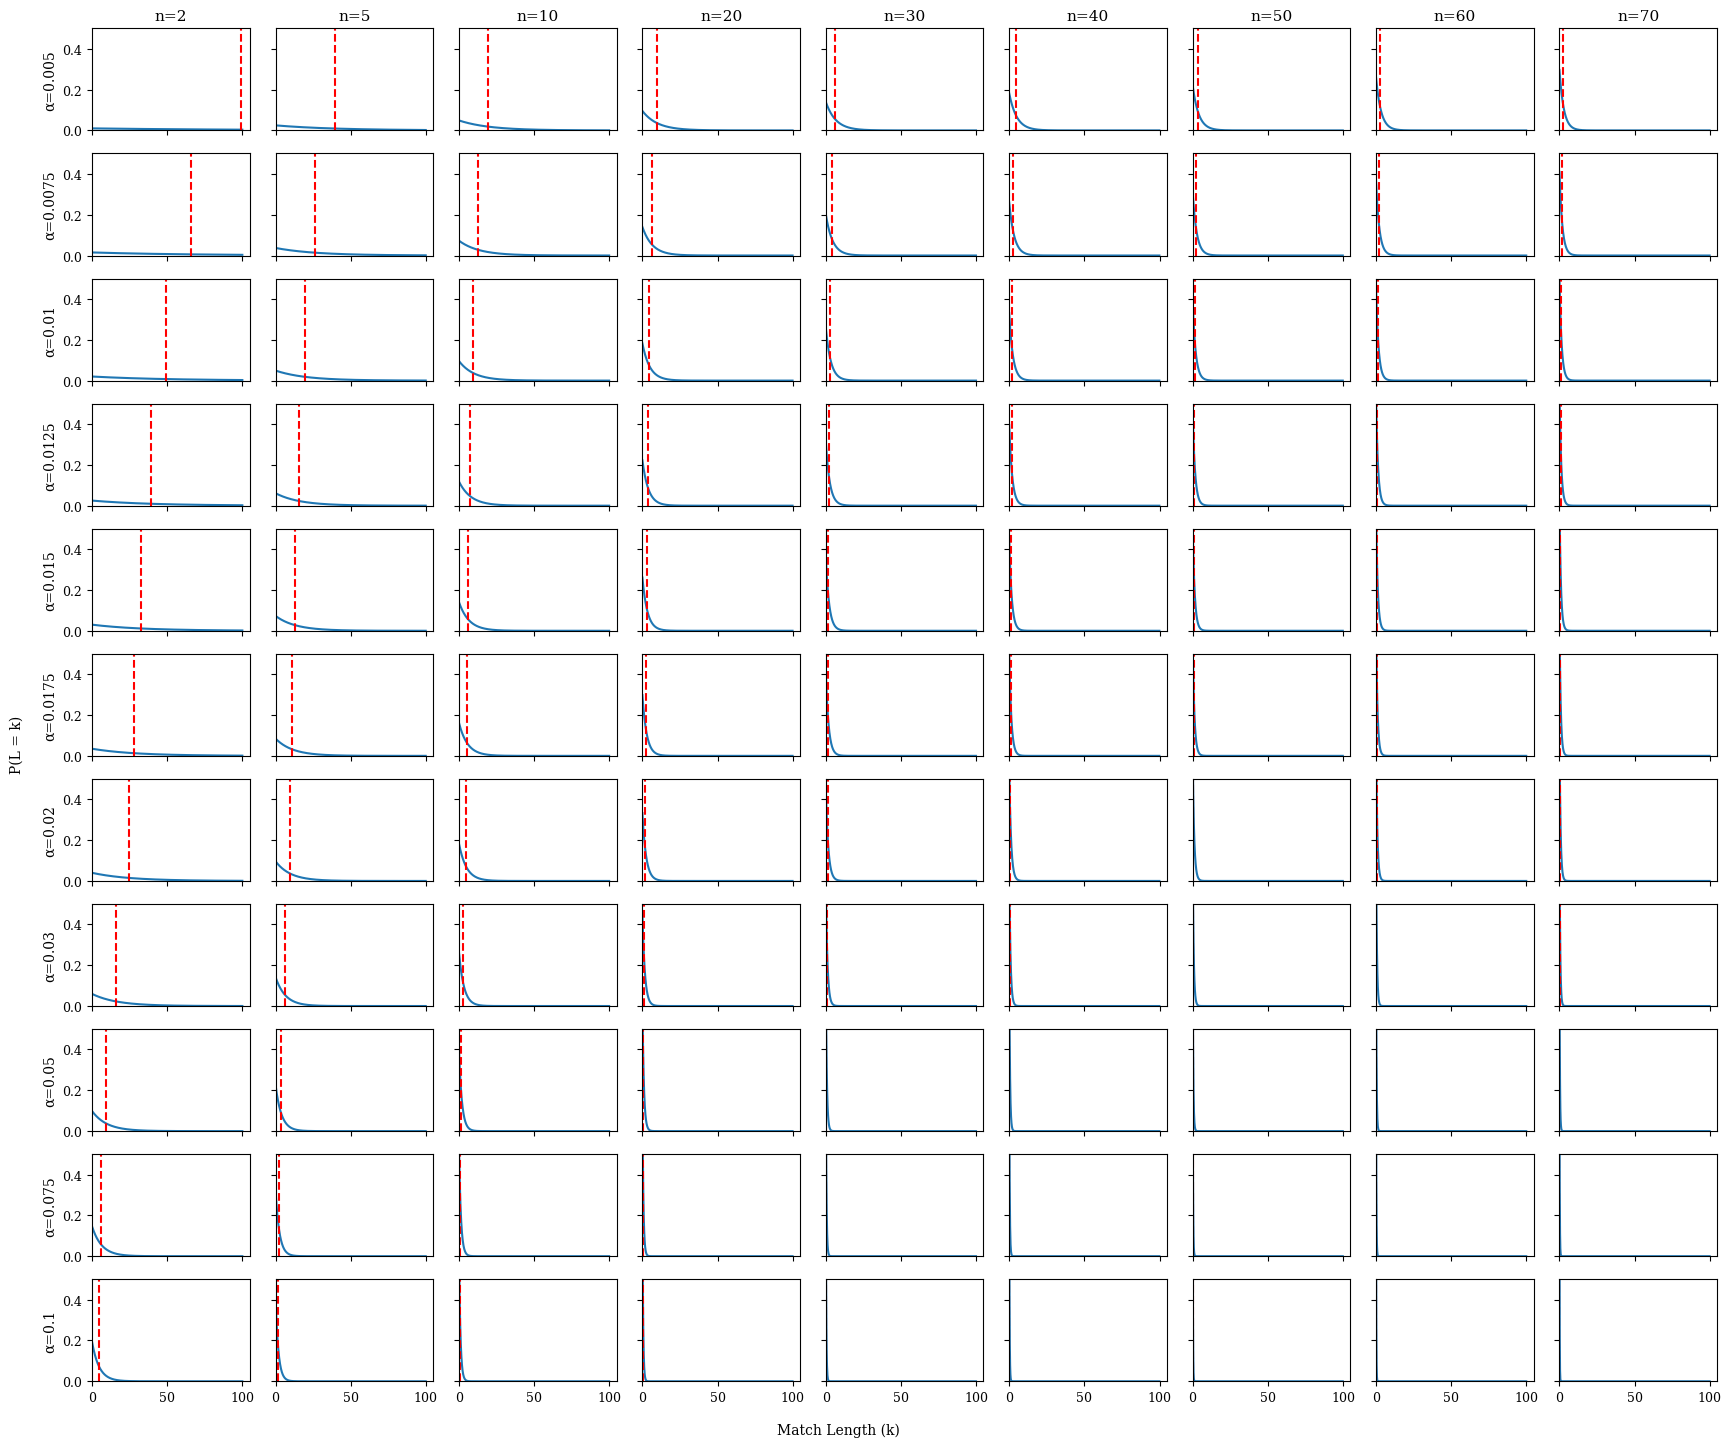

In [3]:
# Parameters
n_values = [2, 5, 10, 20, 30, 40, 50, 60, 70]   # columns
alpha_values = [0.005, 0.0075, 0.01, 0.0125, 0.015, 0.0175, 0.02, 0.03, 0.05, 0.075, 0.1]  # rows
k = np.arange(0, 100, 0.1)  # lengths 0–100

# Create subplot grid
fig, axes = plt.subplots(len(alpha_values), len(n_values), figsize=(18, 15), sharex=True, sharey="row")

for i, alpha in enumerate(alpha_values):
    for j, n in enumerate(n_values):
        ax = axes[i, j]

        p = (1 - alpha) ** n
        P = (p ** k) * (1 - p)

        ax.plot(k, P)
        ax.axvline(x=expected_length(alpha, n), color="red", linestyle="--", label="E[L]")
        ax.set_ylim(0, 0.5)
        # ax.set_yscale("symlog")
        #ax.set_ylim(bottom=0)
        ax.set_xlim(left=0)

        # Column titles (n values)
        if i == 0:
            ax.set_title(f"n={n}")

        # Row labels (alpha values)
        if j == 0:
            ax.set_ylabel(f"α={alpha}")

# Global labels
fig.text(0.5, 0.04, "Match Length (k)", ha="center")
fig.text(0.04, 0.5, "P(L = k)", va="center", rotation="vertical")

plt.tight_layout(rect=[0.05, 0.05, 1, 1])
plt.show()